### **Data Visualization and Insights Extraction**
* Univariate Analysis (Categorical or Continouss)
* Multivariate Analysis (Categorical or Continous)
* Faceting of the Plots
* Advanced Plots and Charts

### **Load the Required Libraries**

In [6]:
import pandas as pd                    ## importing and manipulating df 
import numpy as np                     ## Numeric manipulation
import matplotlib.pyplot as plt        ## For data visualization
import seaborn as sns                  ## For data visualization
from pandas.plotting import scatter_matrix  ## For data visualization
from mpl_toolkits.mplot3d import Axes3D   ## For data visualization
import warnings                        ## Turn off warnings
warnings.filterwarnings('ignore')      ## Actual turning off of the warnings

### **Set up Data Visualization Style**

In [7]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 10

### **Data Importation**

In [24]:
df = pd.read_csv('Clean_GSSsubset.csv')
df.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,HIGH SCHOOL,26722.56,NEVER MARRIED,18,73.2,86.3,35
1,2,MALE,HIGH SCHOOL,36544.91,MARRIED,35,69.9,95.3,47
2,3,FEMALE,HIGH SCHOOL,59587.14,DIVORCED,28,70.1,60.9,16
3,4,FEMALE,GRADUATE,49586.54,MARRIED,43,61.9,76.0,44
4,5,MALE,HIGH SCHOOL,48899.47,MARRIED,48,65.8,58.9,44


### **Display  of Basic Information**

In [25]:
### Dimension
print(f"Display the Dimension of the Data:{df.shape}")

Display the Dimension of the Data:(3000, 9)


In [26]:
### Display the Column Names
print(f"Display the Column Names: {list(df.columns)}")

Display the Column Names: ['id', 'sex', 'degree', 'income', 'marital', 'age', 'height', 'weight', 'hrswrk']


In [27]:
#### Display the Type of Each Variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3000 non-null   int64  
 1   sex      3000 non-null   object 
 2   degree   3000 non-null   object 
 3   income   3000 non-null   float64
 4   marital  3000 non-null   object 
 5   age      3000 non-null   int64  
 6   height   3000 non-null   float64
 7   weight   3000 non-null   float64
 8   hrswrk   3000 non-null   int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 211.1+ KB


### **2. Univariate Analysis**

#### **2.1. Histogram for the Distribution of Income**

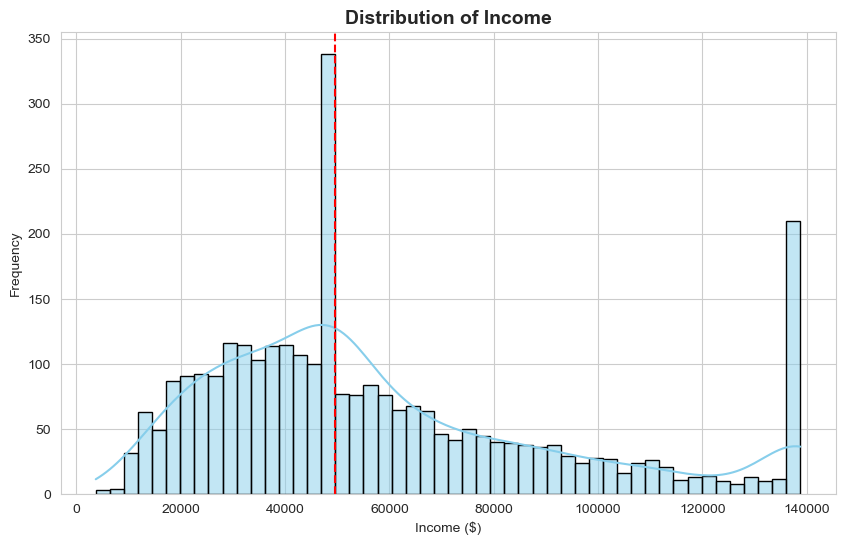

In [32]:
plt.figure(figsize = (10,6))
sns.histplot(df['income'], bins = 50, kde = True, 
             color = 'skyblue', edgecolor = 'black')
plt.title('Distribution of Income', 
          fontsize = 14, fontweight = 'bold')
plt.xlabel('Income ($)')
plt.ylabel('Frequency')
plt.axvline(df['income'].median(), color = 'red',
            linestyle = '--', 
            label = f'Median: ${df['income'].median():,.0f}')
plt.show()

#### **2.2. Income Distribution from a Boxplot**

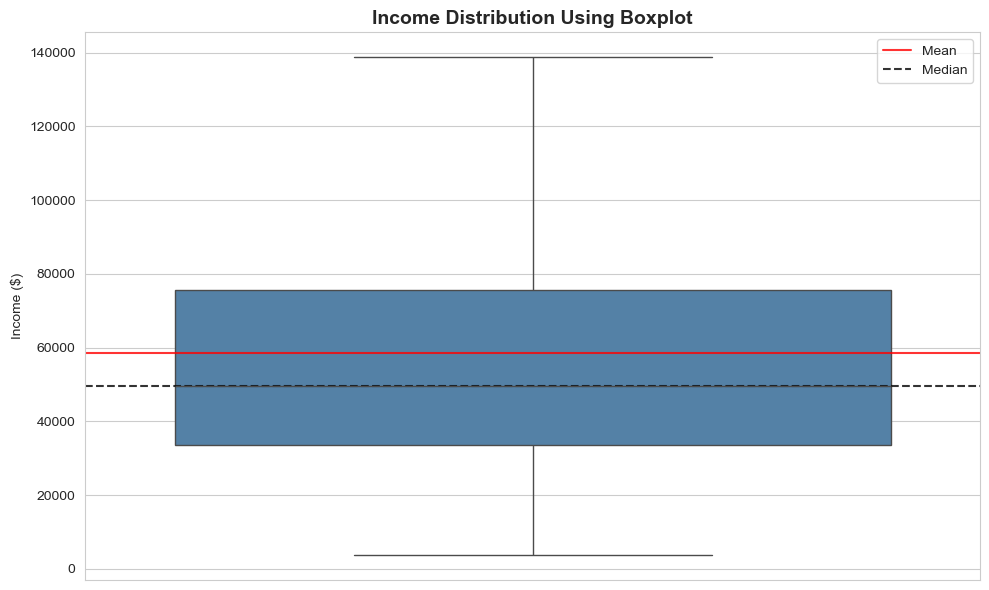

In [40]:
plt.figure(figsize = (10, 6))
sns.boxplot(y = df['income'], color = 'steelblue')
plt.title("Income Distribution Using Boxplot", fontsize = 14, 
          fontweight = 'bold')
plt.ylabel('Income ($)')
plt.axhline(df['income'].mean(), color = 'red',
            linestyle = '-', alpha = 0.8, label = 'Mean')
plt.axhline(df['income'].median(), color = 'black',
            linestyle = '--', alpha = 0.8, label = 'Median')
plt.legend()
plt.tight_layout()
plt.show()

#### **Identification of Outliers Using Boxplot**

In [42]:
df2 = pd.read_csv("GSSsubset1.csv")
df2.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,HIGH SCHOOL,26722.56,NEVER MARRIED,18,73.2,86.3,35.0
1,2,MALE,NaN,36544.91,MARRIED,35,69.9,95.3,47.0
2,3,FEMALE,HIGH SCHOOL,59587.14,DIVORCED,28,70.1,60.9,16.0
3,4,FEMALE,GRADUATE,NaN,MARRIED,43,61.9,76.0,44.0
4,5,MALE,HIGH SCHOOL,48899.47,MARRIED,48,65.8,58.9,44.0


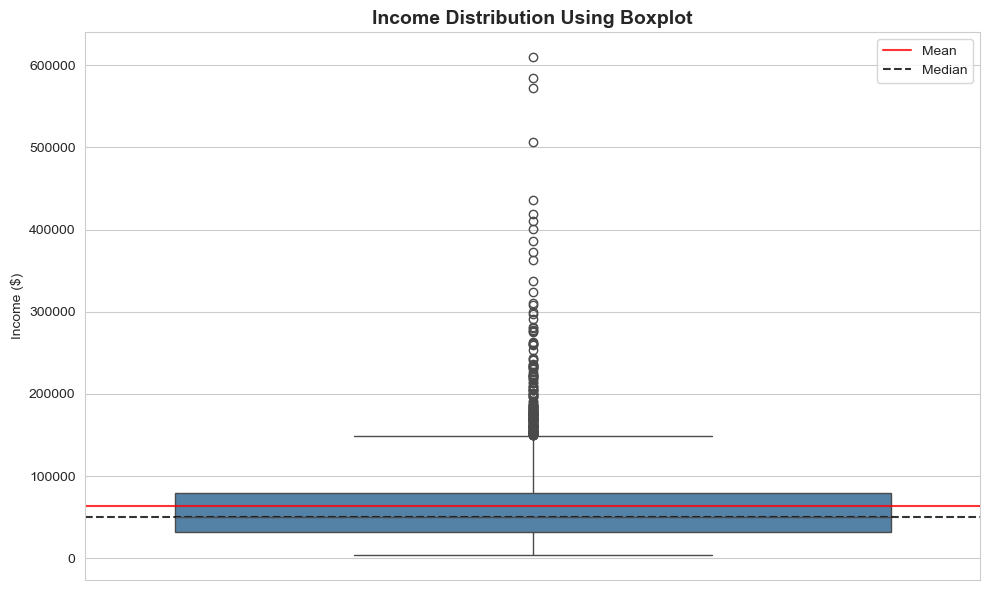

In [43]:
plt.figure(figsize = (10, 6))
sns.boxplot(y = df2['income'], color = 'steelblue')
plt.title("Income Distribution Using Boxplot", fontsize = 14, 
          fontweight = 'bold')
plt.ylabel('Income ($)')
plt.axhline(df2['income'].mean(), color = 'red',
            linestyle = '-', alpha = 0.8, label = 'Mean')
plt.axhline(df2['income'].median(), color = 'black',
            linestyle = '--', alpha = 0.8, label = 'Median')
plt.legend()
plt.tight_layout()
plt.show()

#### **2.3. Age Distribution Using Histogram and Violin Plots**

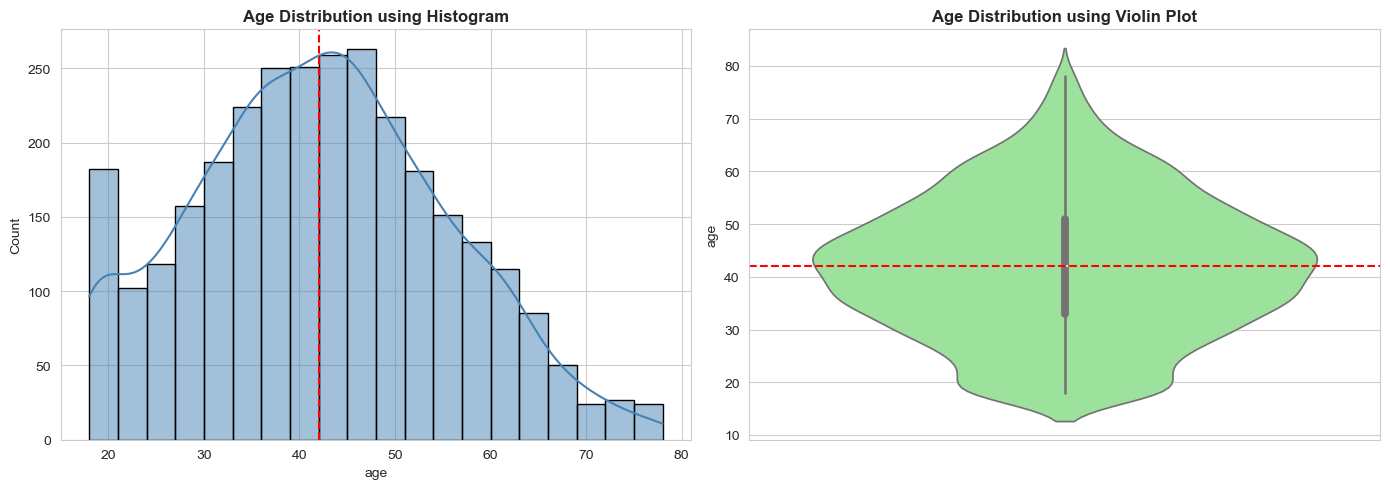

In [47]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sns.histplot(df['age'], bins = 20, kde = True, ax=axes[0],
             color = 'steelblue', edgecolor = 'black')
axes[0].set_title('Age Distribution using Histogram', fontweight = 'bold')
axes[0].axvline(df['age'].mean(), color = 'red', linestyle = '--')

sns.violinplot(y = df['age'], ax = axes[1], color = 'lightgreen')
axes[1].set_title("Age Distribution using Violin Plot", fontweight = 'bold')
axes[1].axhline(df['age'].mean(), color = 'red', linestyle = '--')

plt.tight_layout()
plt.show()

#### **2.4. Joint Distribution Plot - Height and Weight**

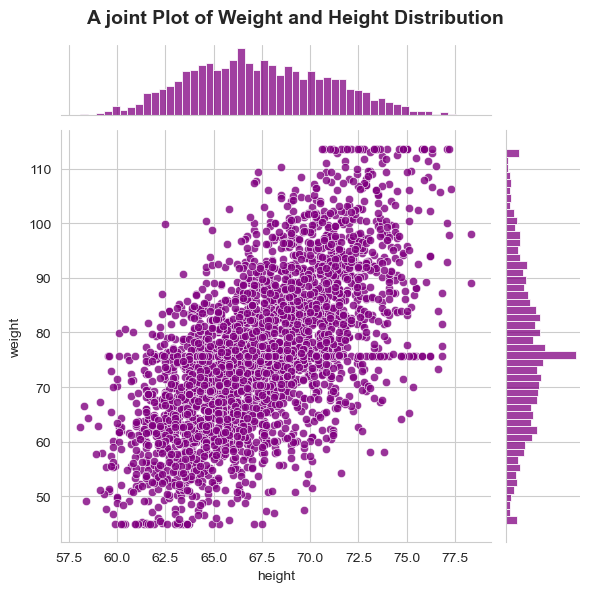

Height and Weight Correlation: 0.643


In [54]:
joint_plot = sns.jointplot(data = df, x = 'height', y = 'weight',
                           kind = 'scatter', alpha = 0.8, color = 'purple',
                           marginal_kws = dict(bins = 50, fill = True))
joint_plot.fig.suptitle('A joint Plot of Weight and Height Distribution',
                        fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

corr_val = df['height'].corr(df['weight'])
print(f"Height and Weight Correlation: {corr_val:.3f}")

### **3. Categorical Variables Analysis**